In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import gc
import warnings
warnings.filterwarnings('ignore')



In [38]:
# load in sampled flight dataset
flight_cols = [
'FlightDate', 'Airline', 'Origin', 'Dest',
'Cancelled', 'CRSDepTime',
'DepDelay', 'DepDelayMinutes',
'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek'
]


flights = pd.read_parquet('../all_flights_2018-2022.parquet', columns=flight_cols)

In [39]:
# changing dtypes for memory efficiency
flights['Cancelled'] = flights['Cancelled'].astype('bool')
flights['Airline'] = flights['Airline'].astype('category')
flights['Origin'] = flights['Origin'].astype('category')
flights['Dest'] = flights['Dest'].astype('category')

print('Flights shape:', flights.shape)


Flights shape: (29193782, 14)


In [40]:
# target variables---> Cancelled, Delayed(>=15min), On time
conditions = [
flights['Cancelled'] == True,
flights['DepDelayMinutes'] >= 15
]
choices = ['Cancelled', 'Delayed']
flights['target'] = np.select(conditions, choices, default='On time')


class_counts = flights['target'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

# target distribution & percentages
print("\nTarget distribution:")
print(class_counts)
print("\nTarget %:")
print((class_counts / class_counts.sum()) * 100)



Target distribution:
target
On time      23512421
Delayed       4904094
Cancelled      777267
Name: count, dtype: int64

Target %:
target
On time      80.53914
Delayed      16.79842
Cancelled     2.66244
Name: count, dtype: float64


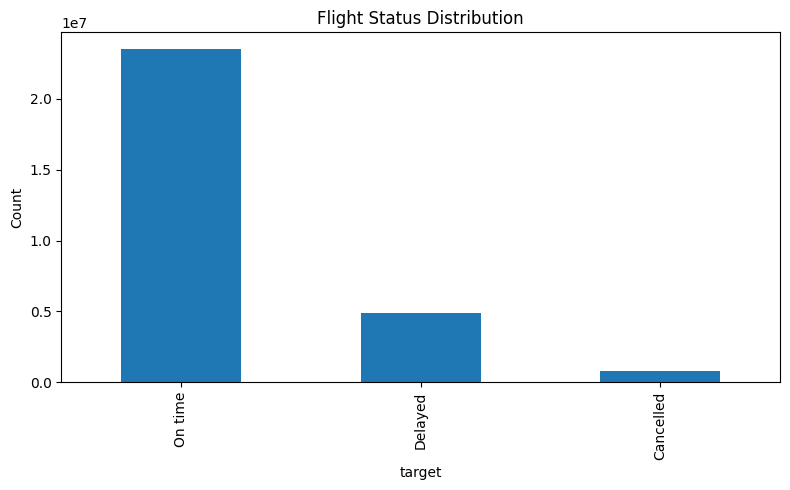

In [41]:
# target dist bar
plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Flight Status Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* shows a major class imbalance: most flights are on time (80%) with some delayed (17%) and even fewer cancelled flights (3%)

**Something we have to keep an eye on!!**
potential fixes:
1. class weights in loss function 
2. stratified sampling to maintain class proportions during training 


In [42]:
# delay distribution (delayed flights only)
delayed = flights[flights['target'] == 'Delayed']['DepDelay'].dropna()
delayed.describe()

count    4.904094e+06
mean     6.864991e+01
std      9.219186e+01
min      1.500000e+01
25%      2.400000e+01
50%      4.100000e+01
75%      7.900000e+01
max      7.223000e+03
Name: DepDelay, dtype: float64

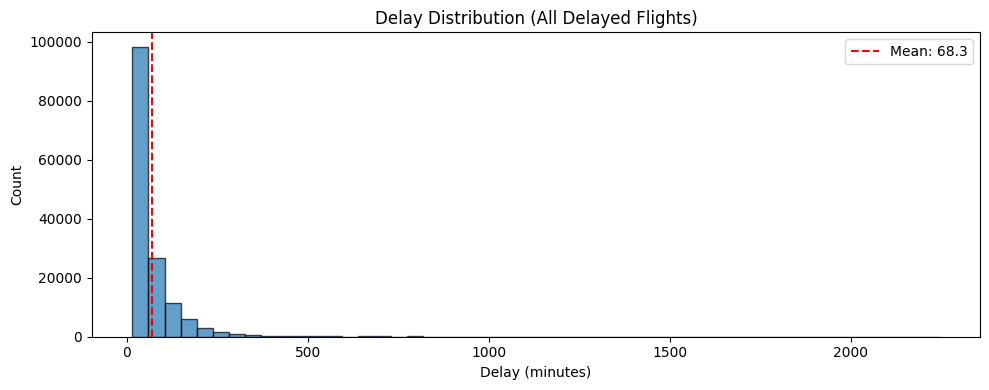

In [43]:
# delayed sample
delayed_sample = delayed.sample(min(150000, len(delayed)), random_state=42)

# histogram for delayed flights
plt.figure(figsize=(10,4))  
plt.hist(delayed_sample, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(delayed_sample.mean(), linestyle='--', label=f"Mean: {delayed_sample.mean():.1f}", color='red')
plt.title('Delay Distribution (All Delayed Flights)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

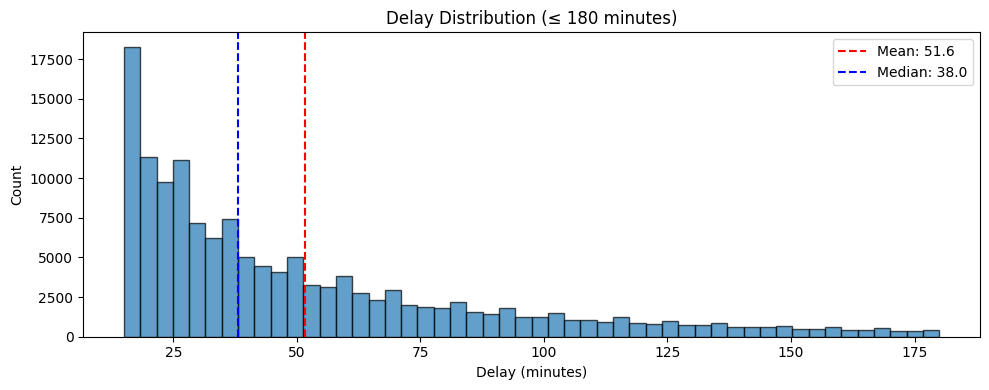

In [44]:
# trimmed hist
delayed_trim = delayed_sample[delayed_sample <= 180]
plt.figure(figsize=(10,4))
plt.hist(delayed_trim, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(delayed_trim.mean(), linestyle='--', label=f"Mean: {delayed_trim.mean():.1f}", color='red')
plt.axvline(delayed_trim.median(), linestyle='--', label=f"Median: {delayed_trim.median():.1f}", color='blue')
plt.title('Delay Distribution (≤ 180 minutes)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

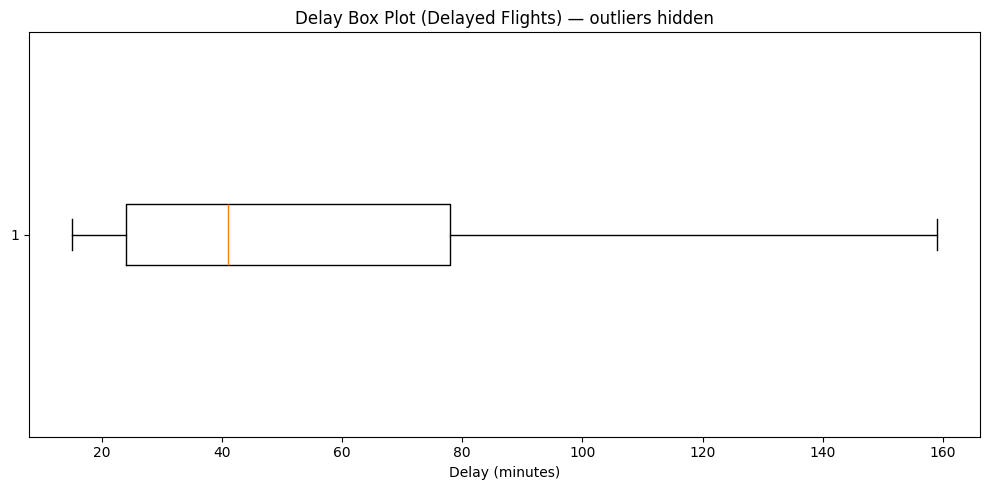


Median: 41.00 minutes
IQR: 54.00 minutes


In [45]:
# boxplot for delayed flights
plt.figure(figsize=(10,5))
plt.boxplot(delayed_sample, vert=False, showfliers=False)
plt.title('Delay Box Plot (Delayed Flights) — outliers hidden')
plt.xlabel('Delay (minutes)')
plt.tight_layout()
plt.show()

median = delayed_sample.median()
iqr = delayed_sample.quantile(0.75) - delayed_sample.quantile(0.25)
print(f'\nMedian: {median:.2f} minutes')
print(f'IQR: {iqr:.2f} minutes')

### Delay Distribution plots 
1. delayed dist hitogram (all flights)
2. delayed dist hist (trimmed)
3. delayed flights boxplot

The distribution for delayed flights is heavily right-skewed with a long tail extending beyond 3 hrs. The median time delay for flights is 41 min with a mean of 69 min. Most delays cluster between 15-60 min. 

- in the trimmed histogram you can see the distribution more clearly 
median < mean. 
- The boxplot shows a lot of extreme outliers (long tail)

- the large difference between mean and median shows that there is a wide range of values representing a "delayed" flight, and one flight being delayed 3 hrs can have drastically different reasons than one flight being delayed 20 min. 

**regression task to capture the difference is delay durations**

In [22]:
# delete vars for memory
del delayed, delayed_sample, delayed_trim
gc.collect()

20514

In [23]:
# Correlation between flight status and delay duration
sample = flights.sample(200000, random_state=42)
sample['target_num'] = sample['target'].map({'On time': 0, 'Delayed': 1, 'Cancelled': 2})
status_delay_corr = sample[['DepDelay', 'target_num']].corr().iloc[0, 1]
print(f'\nCorrelation between Departure Delay and Target: {status_delay_corr:.2f}')

del sample
gc.collect()



Correlation between Departure Delay and Target: 0.57


0

In [24]:
# daily delayed flights stats
daily_stats = flights.groupby('FlightDate').agg({
'DepDelay': 'mean',
'target': lambda x: (x == 'Delayed').mean()
}).reset_index()
daily_stats.columns = ['date', 'avg_delay', 'delay_rate']

print(f'\nNumber of unique days with flight data: {len(daily_stats)}')


Number of unique days with flight data: 1673


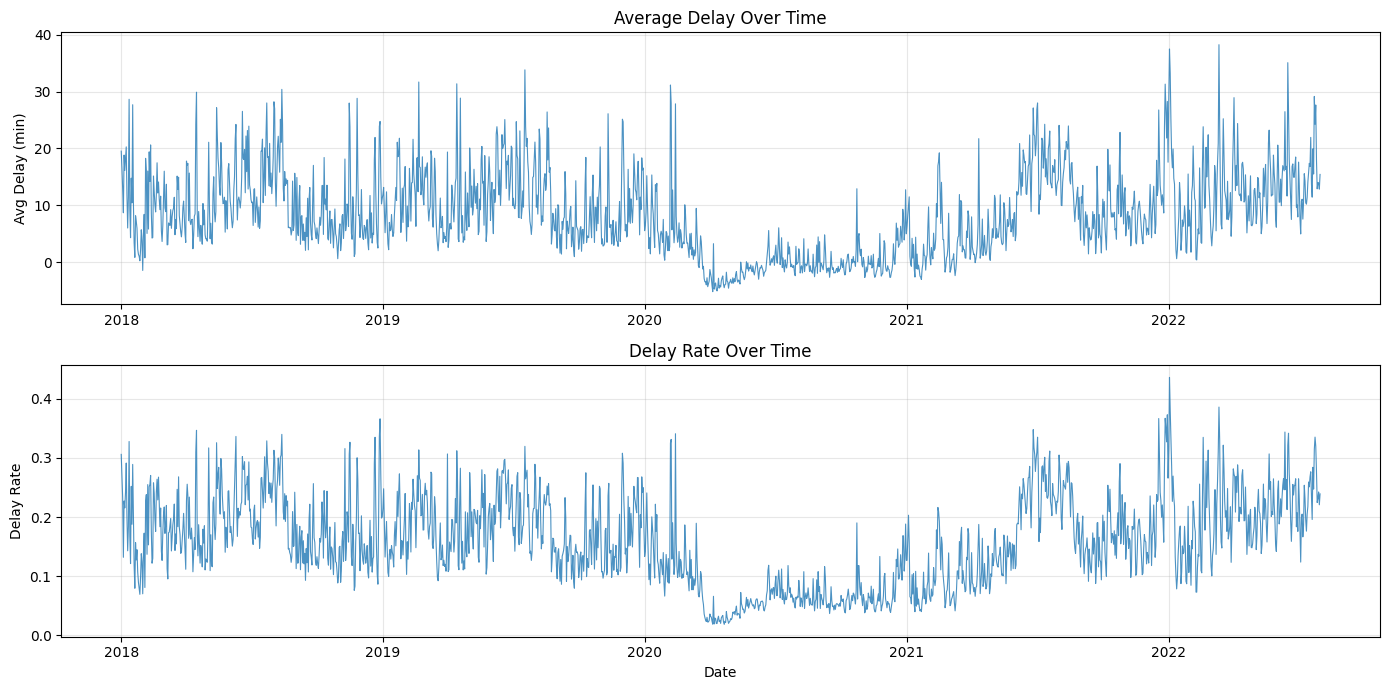

In [25]:
# avg delay and delay rate over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(daily_stats['date'], daily_stats['avg_delay'], linewidth=0.8, alpha=0.8)
axes[0].set_title('Average Delay Over Time')
axes[0].set_ylabel('Avg Delay (min)')
axes[0].grid(alpha=0.3)


axes[1].plot(daily_stats['date'], daily_stats['delay_rate'], linewidth=0.8, alpha=0.8)
axes[1].set_title('Delay Rate Over Time')
axes[1].set_ylabel('Delay Rate')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

### **Time series for delay rate**

- shows us temporal variation across 2018-2019 with notable flunctuations from almost 0 - 30+ mmin average delays. 

- major dip in 2020 --> **covid/lockdown**

* Shows us that delays vary over time due to different factors like, seasonal effects, weather patterns, and opterational factors.

- looking at these plots they seem very similar, which shows us that days with a higher proportion of delayed flights also tend to experience longer average delays.

----> Disruptions affect both how often and how severely flights are delayed. 

### To look for patterns within time series: ACF & PCAF

### **Autocorrelation Function (ACF) + Partial ACF (PCAF)**

**results = signifcant when above shadow blue box**

**ACF**: strong positive autocorrelation at day 1 --> yesterday's delays predict today's then leads to a gradual decrease through day 7.
 
 * tells us that past delays contain predictive info about future delays

**PCAF**: strong partial autocorrelation as day 1, with smaller but still important correlations at days 2-7. 

- since data shows significant results for days 1-7 it can mean that a week of delays can influence current conditions. 


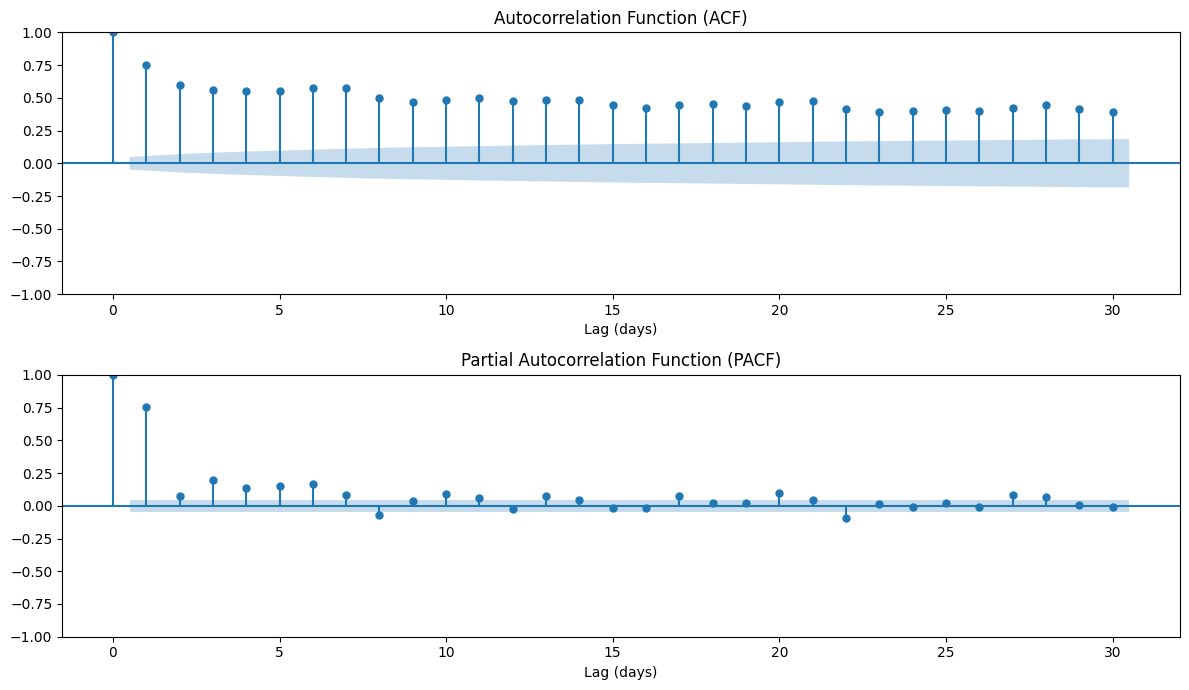

In [26]:
daily_delay = daily_stats.set_index('date')['avg_delay'].dropna()


fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(daily_delay, lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (days)')


plot_pacf(daily_delay, lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (days)')


plt.tight_layout()
plt.show()

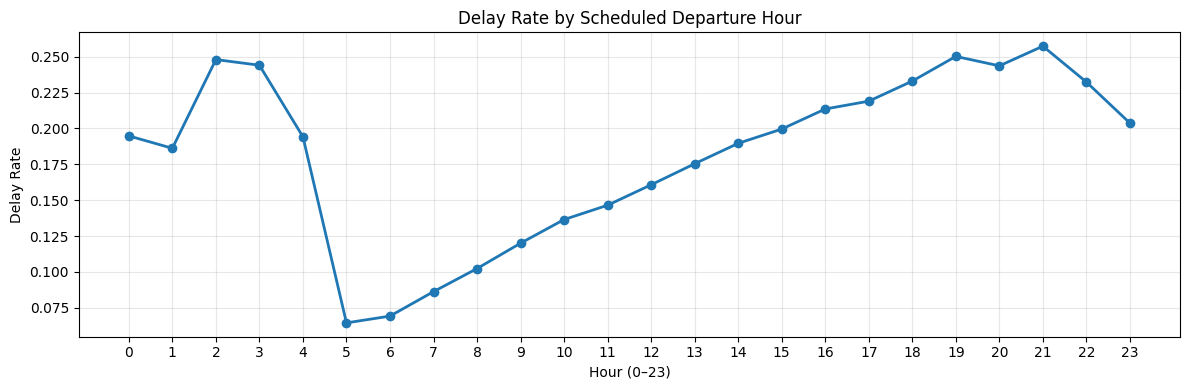

In [27]:
# hour of day pattern
flights['dep_hour'] = flights['CRSDepTime'] // 100


hourly_delays = flights.groupby('dep_hour')['target'].apply(lambda x: (x == 'Delayed').mean()).reset_index()
hourly_delays.columns = ['hour', 'delay_rate']


plt.figure(figsize=(12, 4))
plt.plot(hourly_delays['hour'], hourly_delays['delay_rate'], marker='o', linewidth=2)
plt.title('Delay Rate by Scheduled Departure Hour')
plt.xlabel('Hour (0–23)')
plt.ylabel('Delay Rate')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Delay Rate --- Schedules dep hr
- early mornings (5-7am) have the lowest delay rates
- delay rates increase steadily as day progresses
- evening and late night flights (18-22) experience the highest delay rates

**later flights more likely to delayed due to accumulated delays from earlier delays**

In [ ]:
# merging flights and weather
weather = pd.read_parquet('../weather_airports_2018_2022_CLEAN.parquet')
weather['valid'] = pd.to_datetime(weather['valid'])
weather['date'] = weather['valid'].dt.date
weather['hour'] = weather['valid'].dt.hour


weather_hourly = weather.groupby(['airport_code', 'date', 'hour']).agg({
'tmpf': 'mean',
'vsby': 'mean',
'sknt': 'mean',
'p01i': 'sum',
'relh': 'mean',
'gust': 'max'
}).reset_index()


del weather
gc.collect()

flights['date'] = flights['FlightDate'].dt.date

flights_merged = flights.merge(
weather_hourly,
left_on=['Origin', 'date', 'dep_hour'],
right_on=['airport_code', 'date', 'hour'],
how='left'
).drop(['airport_code', 'hour'], axis=1, errors='ignore') 


weather_coverage = (~flights_merged['tmpf'].isna()).mean() * 100
print(f"Weather data coverage: {weather_coverage:.2f}% of flights")


del weather_hourly
gc.collect()


Loading and aggregating weather data...
Weather data coverage: 60.25% of flights


15


Correlation between weather features and Departure Delay:
vsby   -0.038599
relh   -0.006727
tmpf    0.040436
gust    0.042103
p01i    0.042705
sknt    0.058508
Name: DepDelay, dtype: float64


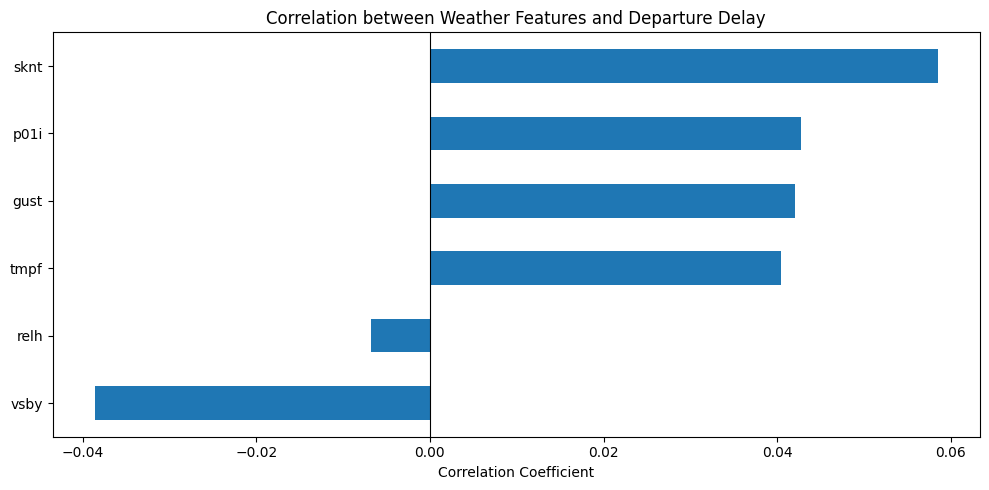

3317

In [29]:
flights_with_weather = flights_merged.dropna(subset=['tmpf']).copy()
weather_cols = ['tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


weather_sample = flights_with_weather.sample(min(200000, len(flights_with_weather)), random_state=42)


weather_corrs = weather_sample[weather_cols + ['DepDelay']].corr()['DepDelay'].drop('DepDelay').sort_values()
print("\nCorrelation between weather features and Departure Delay:")
print(weather_corrs)


plt.figure(figsize=(10, 5))
weather_corrs.plot(kind='barh')
plt.title('Correlation between Weather Features and Departure Delay')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


del weather_sample, flights_with_weather
gc.collect()

### Weather Features Correlations
* meaningful correlation with departure deplays: 

**Positive correlations (associated with longer delays):**
1. sknt (wind speed)
2. gusts (sudden spikes in wind speed)
3. p01i (precipitation)
4. tmpf (temperature)

**Negative Correlations (shorter delays):**
1. vsby (visibility) ---> better visibility reduces delays
2. relh (relative humidity--> fog, clouds)

**Weather conditions are proving to possible being good predictive features**




## **Airports & Airlines**

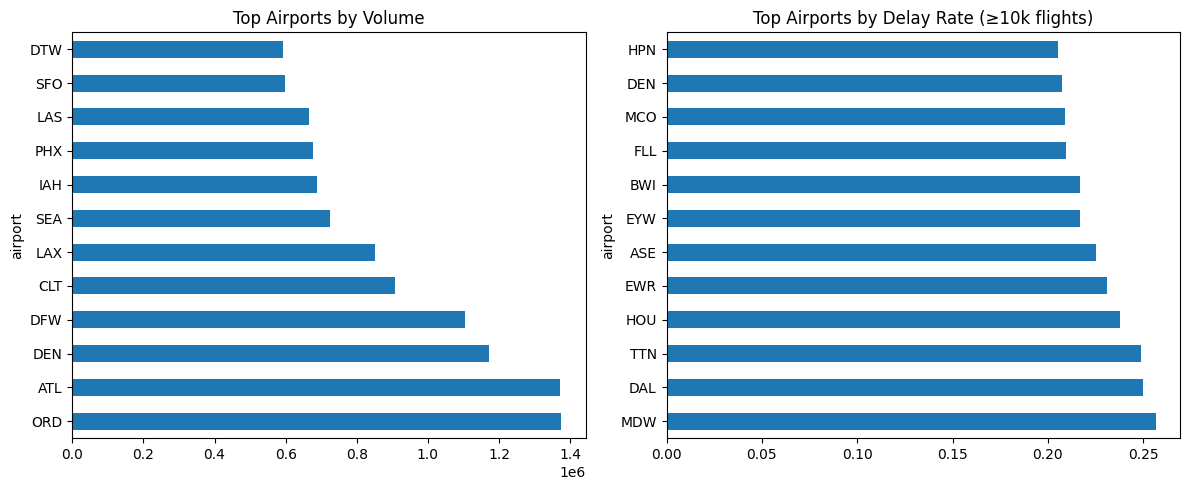

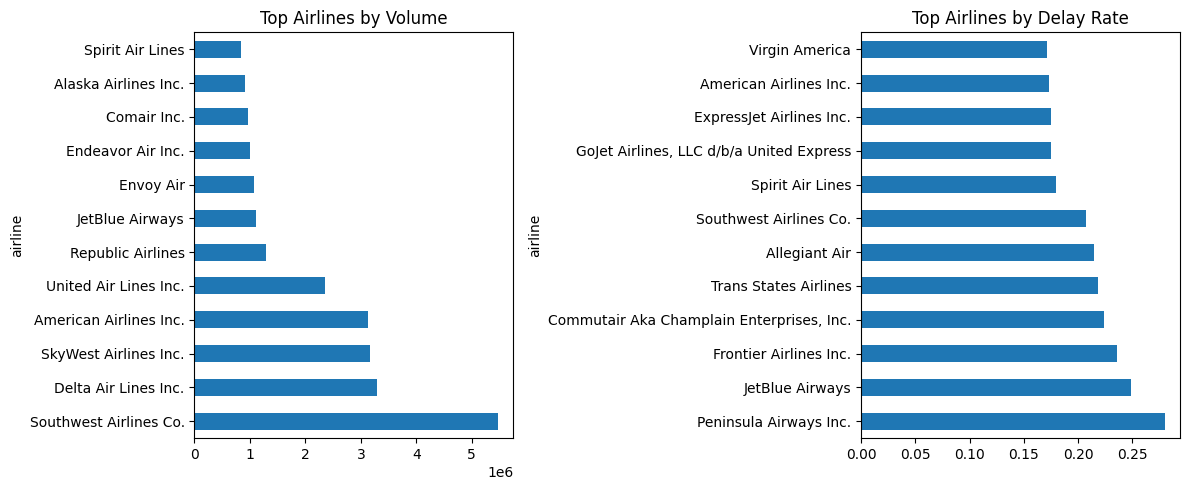

In [30]:
# airport and airline comparisons
airport_stats = flights.groupby('Origin').agg(
flights=('target', 'size'),
delay_rate=('target', lambda x: (x == 'Delayed').mean())
).reset_index().rename(columns={'Origin': 'airport'})


high_volume = airport_stats[airport_stats['flights'] >= 10000]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
airport_stats.nlargest(12, 'flights').plot(x='airport', y='flights', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Top Airports by Volume')


high_volume.nlargest(12, 'delay_rate').plot(x='airport', y='delay_rate', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('Top Airports by Delay Rate (≥10k flights)')


plt.tight_layout()
plt.show()


airline_stats = flights.groupby('Airline').agg(
flights=('target', 'size'),
delay_rate=('target', lambda x: (x == 'Delayed').mean())
).reset_index().rename(columns={'Airline': 'airline'})


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
airline_stats.nlargest(12, 'flights').plot(x='airline', y='flights', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Top Airlines by Volume')


airline_stats.nlargest(12, 'delay_rate').plot(x='airline', y='delay_rate', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('Top Airlines by Delay Rate')


plt.tight_layout()
plt.show()

### Airports
* airports ORD, ATL, DEN have more flights yet they are not seen to have a lot of delays. 

* Smaller airports (with less flights) show higher delay rates

### Airlines
* Southwest has the most flights but maintains moderate delay rates. Smaller airlines (peninsula, jetblue) show the highest delay rates, even though they are not in the top airlines by volume.  

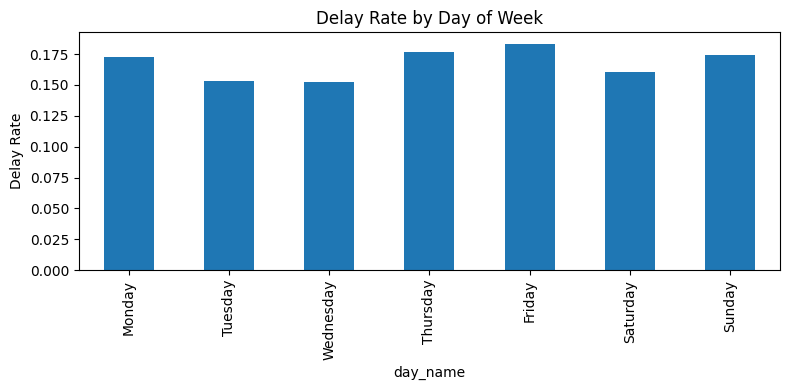

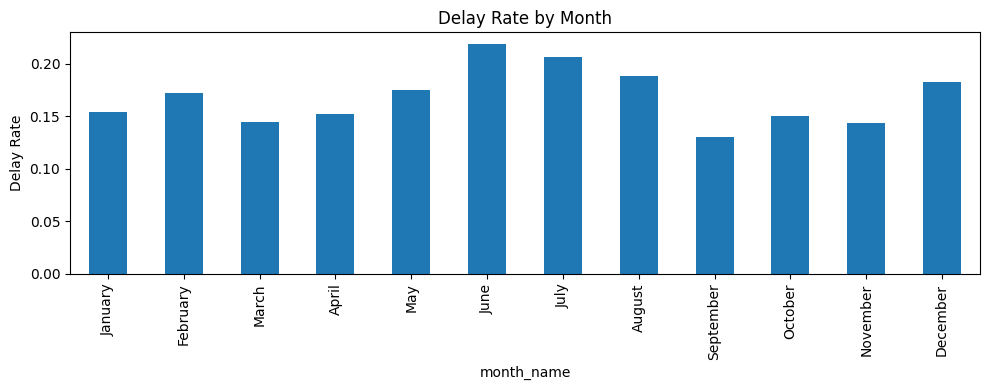

In [31]:
# day of week + month patterns
flights['day_name'] = flights['FlightDate'].dt.day_name()
dow_delays = flights.groupby('day_name')['target'].apply(lambda x: (x == 'Delayed').mean()).reindex(
['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(8, 4))
dow_delays.plot(kind='bar')
plt.title('Delay Rate by Day of Week')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()


flights['month_name'] = flights['FlightDate'].dt.month_name()
month_delays = flights.groupby('month_name')['target'].apply(lambda x: (x == 'Delayed').mean()).reindex(
['January','February','March','April','May','June','July','August','September','October','November','December']
)
plt.figure(figsize=(10, 4))
month_delays.plot(kind='bar')
plt.title('Delay Rate by Month')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()

### Delay by week & month
#### **Day of Week:**
- Friday = highest delay rate, then thursday and monday. mid-week (tuesday-wednesday)  show lower rates

#### **Monthly Patterns:**
- Summer months (June-July) ---> highest delay rates 
- September = lowest rates
- winter months = moderate rates 

**seasonal patterns for model to capture**

### **Pre-Covid Difference in Flights**

* daily average delayes and delay rates show 

In [ ]:
# see the difference in weather impact pre/post COVID
# 2018-2019 
flights = flights[flights['Year'] < 2020].copy()


Top features correlated with delay (flight + weather combined):
dep_hour     0.087497
sknt         0.062503
gust         0.053497
p01i         0.050286
tmpf         0.035421
DayOfWeek    0.011900
Distance     0.010770
relh         0.000163
Month       -0.005979
vsby        -0.043038
Name: DepDelay, dtype: float64


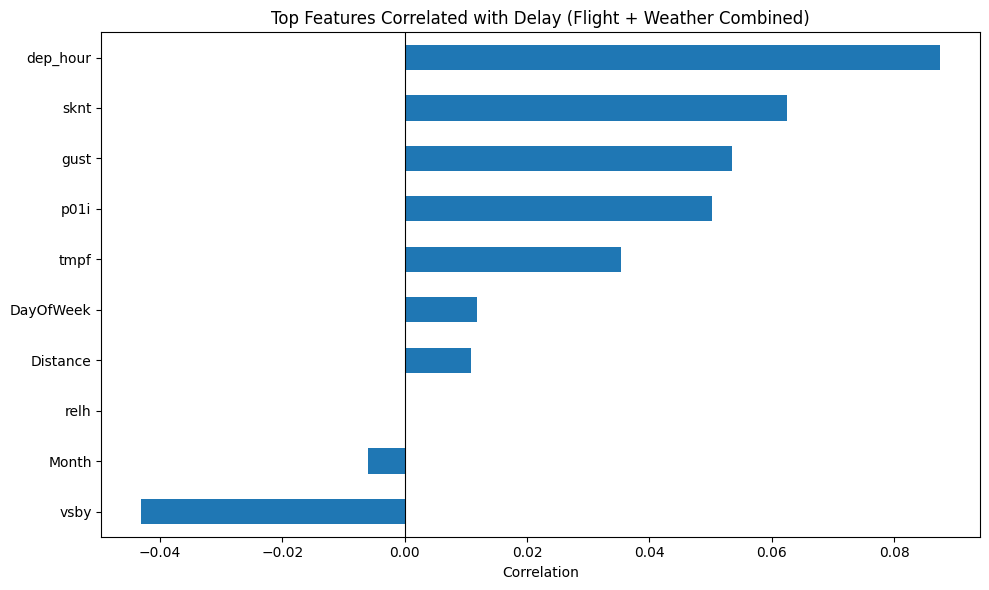

3843

In [34]:
# Combined feature importance (flight + weather together)
print("\nTop features correlated with delay (flight + weather combined):")
sample_merged = flights_merged.sample(min(150000, len(flights_merged)), random_state=42)

feature_cols = ['Distance', 'Month', 'DayOfWeek', 'dep_hour', 
                'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']
feature_cols = [c for c in feature_cols if c in sample_merged.columns and 
                sample_merged[c].notna().sum() > 1000]

all_corrs = sample_merged[feature_cols + ['DepDelay']].corr()['DepDelay'].drop('DepDelay')
print(all_corrs.sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
all_corrs.sort_values().tail(12).plot(kind='barh')
plt.title('Top Features Correlated with Delay (Flight + Weather Combined)')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

del sample_merged
gc.collect()

### **Features Correlated with Delay ---> Flight + Weather (2018-2019)**

* done to avoid the dip/distortion seen in 2020 

* better for explaining delay behavior 

**Strongest Positive Correlations:**
- **dep_hours**
- **sknt**
- **gust**
- **p01i**
- **tmpf**

**Neg corr:**
- **vsby**
- **relh**

**Tells us that the best results will come from combining both flight and weather factors/conditions**